# Rigorous Pipeline Experimentation Suite

Notebook structure:
- Cell 1-5: setup and reusable helpers
- Cell 6-9: instrumented pipeline functions and sweep definitions
- Cell 10-12: orchestrator/CVAE sweeps and pipeline reference run
- Cell 13-14: target length challenge (2..12), figures, cleanup

This notebook is pipeline-only: no non-agentic baseline comparison is executed.

In [2]:
import sys
import random
import time
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import torch

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from peptide_pipeline.dataloader.dataloader_json import DataLoader as JSONDataLoader
from peptide_pipeline.generator.cvae_generator_agent.cvae_generator import CVAEGenerator
from peptide_pipeline.chemist.chemist_agent.chemist_agent import ChemistAgent
from peptide_pipeline.chemist.chemist_agent.config_chemist import ChemistConfig, RangeTarget
from peptide_pipeline.orchestrator.orchestrator_agent.orchestrator import Orchestrator

DATA_PATH = REPO_ROOT / 'database' / 'training_data.json'
EXPERIMENT_DIR = REPO_ROOT / 'experiments' / 'pipeline_experimentations'
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

RUN_PROFILE = 'fast'  # 'fast' or 'full'
RUN_ORCHESTRATOR_SWEEP = True
RUN_CVAE_SWEEP = True
RUN_LENGTH_SWEEP = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'Repo root: {REPO_ROOT}')
print(f'Data path exists: {DATA_PATH.exists()}')
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'Run profile: {RUN_PROFILE}')

Repo root: /home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline
Data path exists: True
CUDA available: True
Run profile: fast


In [3]:
from peptide_pipeline.biologist.esm_l2_bio_agent.esm_biologist_global_l2 import ESMBiologistGlobalL2

TARGET = {
    'dbaasp_id': 'DBAASPS_373',
    'sequence': 'KLFKRWKHLFR',
    'length': 11,
    'ph': 7.0,
    'molecular_weight': 1558.9480000000003,
    'logp': -0.992100000000006,
    'net_charge': 5.0,
    'isoelectric_point': 12.18,
    'hydrophobicity': 1.05,
    'cathionicity': 6,
}

AA = 'ACDEFGHIKLMNPQRSTVWY'
AA_TO_IDX = {aa: i for i, aa in enumerate(AA)}
PAD_IDX = 20
VOCAB_SIZE = 21
MAX_LEN = 14

def build_biologist(reference_peptide: str, score_temperature: float = 50.0):
    return ESMBiologistGlobalL2(
        reference_peptide=reference_peptide,
        batch_size=16,
        score_temperature=score_temperature,
    )

In [4]:
# --- Data Loading ---
VOCAB_SIZE = 21  # 20 AA + PAD
PAD_IDX = 20
MAX_LEN = 14
AA_TO_IDX = {aa: i for i, aa in enumerate("ACDEFGHIKLMNPQRSTVWY")}

def encode_one_hot_with_pad(sequences: List[str], max_len: int = MAX_LEN) -> torch.Tensor:
    x = torch.zeros(len(sequences), max_len * VOCAB_SIZE, dtype=torch.float32)
    for i, seq in enumerate(sequences):
        for pos in range(max_len):
            x[i, pos * VOCAB_SIZE + PAD_IDX] = 1.0
        for pos, aa in enumerate(seq[:max_len]):
            if aa in AA_TO_IDX:
                x[i, pos * VOCAB_SIZE + PAD_IDX] = 0.0
                x[i, pos * VOCAB_SIZE + AA_TO_IDX[aa]] = 1.0
    return x

def build_condition_tensor(dataframe: pd.DataFrame, condition_dim: int = 32) -> torch.Tensor:
    cond = torch.zeros(len(dataframe), condition_dim, dtype=torch.float32)
    # Map dataframe columns to condition tensor explicitly
    cond[:, 0] = torch.tensor(dataframe['length'].values, dtype=torch.float32)
    cond[:, 1] = torch.tensor(dataframe['molecular_weight'].values, dtype=torch.float32)
    cond[:, 2] = torch.tensor(dataframe['net_charge'].values, dtype=torch.float32)
    cond[:, 3] = torch.tensor(dataframe['isoelectric_point'].values, dtype=torch.float32)
    cond[:, 4] = torch.tensor(dataframe['hydrophobicity'].values, dtype=torch.float32)
    cond[:, 5] = torch.tensor(dataframe['cathionicity'].values, dtype=torch.float32)
    cond[:, 6] = 0.5 # Default hydrophobic moment
    cond[:, 7] = torch.tensor(dataframe['logp'].values, dtype=torch.float32)
    # Remaining dimensions filled with defaults or ignored by CVAE depending on implementation
    return cond

loader = JSONDataLoader()
loader.load_data(
    source=str(DATA_PATH),
    columns=[
        'sequence', 'length', 'ph', 'molecular_weight', 'logp',
        'net_charge', 'isoelectric_point', 'hydrophobicity', 'cathionicity'
    ],
    fillna_defaults={
        'length': 10,
        'ph': 7.0,
        'molecular_weight': 1500.0,
        'logp': 0.0,
        'net_charge': 0.0,
        'isoelectric_point': 7.0,
        'hydrophobicity': 0.0,
        'cathionicity': 0.0,
    },
    normalize_sequence=True,
    sequence_column='sequence',
    keep_standard_amino_acids_only=True,
)

df = loader.get_data().copy()
sequences = df['sequence'].tolist()
lengths_t = torch.tensor(df['length'].astype(int).values, dtype=torch.long)
x_t = encode_one_hot_with_pad(sequences, max_len=MAX_LEN)
conditions_t = build_condition_tensor(df, condition_dim=32)

print(f'Dataset rows: {len(df)}')
print(f'x shape: {tuple(x_t.shape)}')
print(f'conditions shape: {tuple(conditions_t.shape)}')
display(df.head(3))

Dataset rows: 4410
x shape: (4410, 294)
conditions shape: (4410, 32)


,sequence,length,ph,molecular_weight,logp,net_charge,isoelectric_point,hydrophobicity,cathionicity
0,KVVVKWVVKVVK,12,7.0,1648.291,5.6026,5.0,14.0,-1.07,4
1,LFIFFF,6,7.0,832.059,3.2860,1.0,14.0,-3.25,0
2,KAAAKWAAKAAK,12,7.0,1451.913,1.1499,5.0,14.0,0.33,4


In [5]:
# --- Model Helpers ---

def build_chemist_from_target(
    target: Dict[str, Any],
    width_scale: float = 1.0,
    length_min: float = 2.0,
    length_max: float = 20.0,
    length_weight: float = 1.0,
) -> ChemistAgent:
    ph = float(target['ph'])
    target_length = float(target['length'])
    min_len = max(length_min, target_length if width_scale <= 1.0 else target_length - 1.0)
    max_len = min(length_max, target_length if width_scale <= 1.0 else target_length + 1.0)

    target_mw = float(target['molecular_weight'])
    mw_span = max(250.0, 0.35 * target_mw)
    mw_min = max(200.0, target_mw - mw_span)
    mw_max = target_mw + mw_span

    target_charge = float(target['net_charge'])
    charge_span = max(1.5, 0.5 * abs(target_charge) * width_scale)
    charge_min = target_charge - charge_span
    charge_max = target_charge + charge_span

    target_ip = float(target['isoelectric_point'])
    ip_span = 2.5 * width_scale
    ip_min = max(3.0, target_ip - ip_span)
    ip_max = min(14.0, target_ip + ip_span)

    target_hydro = float(target['hydrophobicity'])
    hydro_span = 1.5 * width_scale
    hydro_min = target_hydro - hydro_span
    hydro_max = target_hydro + hydro_span

    target_logp = float(target['logp'])
    logp_span = 2.0 * width_scale
    logp_min = target_logp - logp_span
    logp_max = target_logp + logp_span

    return ChemistAgent(
        config=ChemistConfig(
            ph=ph,
            length=RangeTarget(min=min_len, max=max_len, target=target_length, weight=length_weight),
            molecular_weight=RangeTarget(min=mw_min, max=mw_max, target=target_mw, weight=1.0),
            logp=RangeTarget(min=logp_min, max=logp_max, target=target_logp, weight=1.0),
            net_charge=RangeTarget(min=charge_min, max=charge_max, target=target_charge, weight=1.0),
            isoelectric_point=RangeTarget(min=ip_min, max=ip_max, target=target_ip, weight=1.0),
            hydrophobicity=RangeTarget(min=hydro_min, max=hydro_max, target=target_hydro, weight=1.0),
        )
    )

def model_cache_path(
    latent_dim: int,
    hidden_dim: int,
    epochs: int,
    lr: float,
    kl_anneal_epochs: int = 0,
    batch_size: int = 64,
) -> Path:
    lr_text = str(lr).replace('.', 'p')
    return EXPERIMENT_DIR / (
        f'cvae_lat{latent_dim}_hid{hidden_dim}_ep{epochs}_lr{lr_text}'
        f'_kl{kl_anneal_epochs}_bs{batch_size}.pth'
    )

def get_or_train_cvae(
    latent_dim: int,
    hidden_dim: int,
    epochs: int,
    lr: float,
    kl_anneal_epochs: int,
    batch_size: int = 64,
) -> CVAEGenerator:
    model = CVAEGenerator(max_len=MAX_LEN, latent_dim=latent_dim, hidden_dim=hidden_dim, condition_dim=32)
    path = model_cache_path(
        latent_dim=latent_dim,
        hidden_dim=hidden_dim,
        epochs=epochs,
        lr=lr,
        kl_anneal_epochs=kl_anneal_epochs,
        batch_size=batch_size,
    )

    if path.exists():
        model.load_model(str(path))
        print(f"Loaded cached model: {path.name}")
        return model

    print(f"Training CVAE model: {path.name}")
    model.train_model(
        data=x_t,
        conditions=conditions_t,
        lengths=lengths_t,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        kl_anneal_epochs=kl_anneal_epochs,
    )
    model.save_model(str(path))
    print(f"Saved model: {path.name}")
    return model

In [6]:
# --- Experiment Helpers ---

def safe_float(x: Any, default: float = 0.0) -> float:
    try:
        return float(x)
    except Exception:
        return default

def sequence_distance(a: str, b: str) -> float:
    n = max(len(a), len(b), 1)
    a_pad = a.ljust(n, '-')
    b_pad = b.ljust(n, '-')
    return sum(c1 != c2 for c1, c2 in zip(a_pad, b_pad)) / n

def mean_pairwise_distance(peptides: List[str]) -> float:
    if len(peptides) < 2:
        return 0.0
    dists = []
    for i in range(len(peptides)):
        for j in range(i + 1, len(peptides)):
            dists.append(sequence_distance(peptides[i], peptides[j]))
    return float(np.mean(dists)) if dists else 0.0

def bigram_entropy(peptides: List[str]) -> float:
    from collections import Counter
    counts = Counter()
    total = 0
    for p in peptides:
        for i in range(max(0, len(p) - 1)):
            counts[p[i:i+2]] += 1
            total += 1
    if total == 0:
        return 0.0
    probs = np.array([v / total for v in counts.values()], dtype=float)
    return float(-(probs * np.log2(probs + 1e-12)).sum())

def summarize_topk(top_rows: List[Dict[str, Any]], top_k: int = 10) -> Dict[str, float]:
    if not top_rows:
        return {
            'top1_score': 0.0,
            'topk_mean_score': 0.0,
            'validity_rate': 0.0,
            'unique_ratio': 0.0,
            'mean_pairwise_distance': 0.0,
            'bigram_entropy': 0.0,
        }

    top = top_rows[:top_k]
    scores = [safe_float(r.get('combined_score', r.get('score', 0.0))) for r in top]
    peptides = [r.get('peptide', '') for r in top if r.get('peptide')]
    valid = [bool(r.get('in_limits', False)) for r in top]

    return {
        'top1_score': float(max(scores)) if scores else 0.0,
        'topk_mean_score': float(np.mean(scores)) if scores else 0.0,
        'validity_rate': float(np.mean(valid)) if valid else 0.0,
        'unique_ratio': float(len(set(peptides)) / max(len(peptides), 1)),
        'mean_pairwise_distance': mean_pairwise_distance(peptides),
        'bigram_entropy': bigram_entropy(peptides),
    }

def run_instrumented_pipeline(
    generator: CVAEGenerator,
    chemist: ChemistAgent,
    biologist: Any,
    final_target: Dict[str, Any],
    nb_iterations: int,
    nb_peptides: int,
    top_k: int,
    exploration_rate: float,
    random_parent_count: int,
    initial_peptide: str = None,
    target_constraints: Dict[str, Any] = None,
) -> Tuple[List[Dict[str, Any]], pd.DataFrame]:
    orchestrator = Orchestrator(generator=generator, chemist=chemist, biologist=biologist)
    top_rows = orchestrator.run(
        nb_iterations=nb_iterations,
        nb_peptides=nb_peptides,
        top_k=top_k,
        exploration_rate=exploration_rate,
        initial_peptide=initial_peptide or final_target.get('sequence'),
        final_target=target_constraints or final_target,
        random_parent_count=random_parent_count,
    )

    trace_rows: List[Dict[str, Any]] = []
    if top_rows:
        by_iter = pd.DataFrame(top_rows).groupby('iteration', as_index=False)
        for _, chunk in by_iter:
            trace_rows.append(
                {
                    'iteration': int(chunk['iteration'].iloc[0]),
                    'returned_count': int(len(chunk)),
                    'best_combined_score': float(chunk['combined_score'].max()),
                    'mean_combined_score': float(chunk['combined_score'].mean()),
                    'validity_rate_returned': float(chunk['in_limits'].astype(float).mean()),
                }
            )

    trace_df = pd.DataFrame(trace_rows).sort_values('iteration').reset_index(drop=True) if trace_rows else pd.DataFrame()
    return top_rows, trace_df

In [7]:
# --- Aggregation Helper ---

def aggregate_experiment_runs(
    raw_df: pd.DataFrame,
    group_cols: List[str],
    metric_cols: List[str],
    keep_first_cols: List[str] = None,
) -> pd.DataFrame:
    if raw_df.empty:
        return pd.DataFrame()

    agg_map: Dict[str, Any] = {col: ['mean', 'std'] for col in metric_cols}
    for col in keep_first_cols or []:
        agg_map[col] = 'first'

    out = raw_df.groupby(group_cols, as_index=False).agg(agg_map)
    out.columns = ['_'.join(c).strip('_') for c in out.columns]
    return out

print('Aggregation helper ready.')

Aggregation helper ready.


In [8]:
# One dictionary to configure all tests.

TESTS = {
    'profile': RUN_PROFILE,
    'repeats': 2 if RUN_PROFILE == 'fast' else 10,
    'orchestrator_baseline': {
        'nb_iterations': 20,
        'nb_peptides': 128,
        'top_k': 10,
        'exploration_rate': 0.1,
        'random_parent_count': 4,
    },
    'cvae_baseline': {
        'latent_dim': 64,
        'hidden_dim': 256,
        'epochs': 120,
        'lr': 0.001,
        'kl_anneal_epochs': 40,
        'batch_size': 64,
    },
    'orchestrator_variants': {
        'nb_iterations': [1, 2, 4, 8, 12, 16] if RUN_PROFILE == 'fast' else [5, 10, 30, 50, 75],
        'nb_peptides': [10, 50, 100, 200, 400] if RUN_PROFILE == 'fast' else [64, 128, 256, 384, 512],
        'top_k': [5, 20, 32] if RUN_PROFILE == 'fast' else [5, 10, 20, 32, 50],
        'exploration_rate': [0.0, 0.25, 0.5, 0.75] if RUN_PROFILE == 'fast' else [0.0, 0.1, 0.2, 0.4, 0.6, 0.8],
        'random_parent_count': [0, 8, 16, 32] if RUN_PROFILE == 'fast' else [0, 4, 10, 20, 32],
    },
    'cvae_variants': {
        'latent_dim': [32, 96, 128] if RUN_PROFILE == 'fast' else [32, 64, 96, 128, 160],
        'hidden_dim': [128, 384, 512] if RUN_PROFILE == 'fast' else [128, 256, 384, 512],
        'epochs': [80, 160, 240] if RUN_PROFILE == 'fast' else [60, 120, 200, 280],
        'lr': [0.0005, 0.0007, 0.0015] if RUN_PROFILE == 'fast' else [0.0003, 0.0005, 0.0007, 0.001, 0.0015],
        'kl_anneal_epochs': [10, 20, 80, 120] if RUN_PROFILE == 'fast' else [5, 10, 20, 40, 80, 120],
        'batch_size': [32, 128] if RUN_PROFILE == 'fast' else [32, 64, 128],
    },
    'orchestrator_combo_variants': [
        {
            'name': 'combo_quality_focus',
            'overrides': {'nb_iterations': 40, 'nb_peptides': 192, 'top_k': 20, 'exploration_rate': 0.2, 'random_parent_count': 8},
        },
        {
            'name': 'combo_throughput_focus',
            'overrides': {'nb_iterations': 12, 'nb_peptides': 384, 'top_k': 12, 'exploration_rate': 0.05, 'random_parent_count': 0},
        },
        {
            'name': 'combo_exploration_focus',
            'overrides': {'nb_iterations': 30, 'nb_peptides': 128, 'top_k': 16, 'exploration_rate': 0.7, 'random_parent_count': 20},
        },
    ],
    'cvae_combo_variants': [
        {
            'name': 'combo_compact_fast',
            'overrides': {'latent_dim': 32, 'hidden_dim': 128, 'epochs': 100, 'lr': 0.0015, 'kl_anneal_epochs': 20, 'batch_size': 128},
        },
        {
            'name': 'combo_capacity_focus',
            'overrides': {'latent_dim': 128, 'hidden_dim': 512, 'epochs': 220, 'lr': 0.0007, 'kl_anneal_epochs': 80, 'batch_size': 64},
        },
        {
            'name': 'combo_regularized',
            'overrides': {'latent_dim': 96, 'hidden_dim': 384, 'epochs': 180, 'lr': 0.0005, 'kl_anneal_epochs': 120, 'batch_size': 32},
        },
    ],
    'length_candidates': list(range(2, 13)),
}

BASELINE_ORCHESTRATOR = TESTS['orchestrator_baseline']
BASELINE_CVAE = TESTS['cvae_baseline']
ORCHESTRATOR_VARIANTS = TESTS['orchestrator_variants']
CVAE_VARIANTS = TESTS['cvae_variants']
ORCHESTRATOR_COMBO_VARIANTS = TESTS['orchestrator_combo_variants']
CVAE_COMBO_VARIANTS = TESTS['cvae_combo_variants']
REPEATS = TESTS['repeats']

print(f"Run Profile: {TESTS['profile']}")
print(f"Repeats per experiment: {REPEATS}")
print(f"Orchestrator one-at-a-time variants: {sum(len(v) for v in ORCHESTRATOR_VARIANTS.values())}")
print(f"CVAE one-at-a-time variants: {sum(len(v) for v in CVAE_VARIANTS.values())}")
print(f"Orchestrator combo variants: {len(ORCHESTRATOR_COMBO_VARIANTS)}")
print(f"CVAE combo variants: {len(CVAE_COMBO_VARIANTS)}")

Run Profile: fast
Repeats per experiment: 2
Orchestrator one-at-a-time variants: 22
CVAE one-at-a-time variants: 18
Orchestrator combo variants: 3
CVAE combo variants: 3


In [9]:
orchestrator_records = []
orchestrator_traces = []

if RUN_ORCHESTRATOR_SWEEP:
    print("Training CVAE baseline for orchestrator sweep...")
    fixed_model = get_or_train_cvae(**BASELINE_CVAE)
    biologist = build_biologist(TARGET['sequence'], score_temperature=50.0)

    experiment_tasks = []
    experiment_tasks.append({
        'name': 'Baseline',
        'params': BASELINE_ORCHESTRATOR.copy(),
        'param_name': 'baseline',
        'param_value': 'baseline',
        'sweep_group': 'baseline',
    })

    for param_key, variants in ORCHESTRATOR_VARIANTS.items():
        for val in variants:
            cfg = BASELINE_ORCHESTRATOR.copy()
            cfg[param_key] = val
            experiment_tasks.append({
                'name': f"{param_key}={val}",
                'params': cfg,
                'param_name': param_key,
                'param_value': val,
                'sweep_group': 'one_at_a_time',
            })

    for combo in ORCHESTRATOR_COMBO_VARIANTS:
        cfg = BASELINE_ORCHESTRATOR.copy()
        cfg.update(combo['overrides'])
        experiment_tasks.append({
            'name': combo['name'],
            'params': cfg,
            'param_name': 'combo_profile',
            'param_value': combo['name'],
            'sweep_group': 'combo',
        })

    print(f"Total Orchestrator Configurations to run: {len(experiment_tasks)}")

    for i, task in enumerate(experiment_tasks, start=1):
        run_cfg = task['params']
        param_name = task['param_name']
        param_val = task['param_value']
        sweep_group = task['sweep_group']

        per_cfg_metrics = []
        per_cfg_times = []
        total_generated = int(run_cfg['nb_iterations'] * run_cfg['nb_peptides'])

        print(f"Processing config {i}/{len(experiment_tasks)}: {task['name']} (Repeats: {REPEATS})")

        for rep in range(1, REPEATS + 1):
            seed_val = SEED + 10_000 + (100 * i) + rep
            random.seed(seed_val)
            np.random.seed(seed_val)
            torch.manual_seed(seed_val)

            chemist = build_chemist_from_target(TARGET)

            run_start = time.perf_counter()
            top_rows, trace_df = run_instrumented_pipeline(
                generator=fixed_model,
                chemist=chemist,
                biologist=biologist,
                final_target=TARGET,
                nb_iterations=run_cfg['nb_iterations'],
                nb_peptides=run_cfg['nb_peptides'],
                top_k=run_cfg['top_k'],
                exploration_rate=run_cfg['exploration_rate'],
                random_parent_count=run_cfg['random_parent_count'],
            )
            elapsed_sec = float(time.perf_counter() - run_start)

            metrics = summarize_topk(top_rows)
            per_cfg_metrics.append(metrics)
            per_cfg_times.append(elapsed_sec)

            orchestrator_records.append(
                {
                    'config_name': task['name'],
                    'sweep_group': sweep_group,
                    'param_name': param_name,
                    'param_value': param_val,
                    'repeat': rep,
                    'total_generated': total_generated,
                    'elapsed_sec': elapsed_sec,
                    **run_cfg,
                    **metrics,
                }
            )

            if not trace_df.empty:
                trace_df = trace_df.copy()
                trace_df['config_name'] = task['name']
                trace_df['sweep_group'] = sweep_group
                trace_df['repeat'] = rep
                trace_df['elapsed_sec'] = elapsed_sec
                orchestrator_traces.append(trace_df)

        top1_vals = [m['top1_score'] for m in per_cfg_metrics]
        mean_top1 = np.mean(top1_vals)
        std_top1 = np.std(top1_vals, ddof=1) if len(top1_vals) > 1 else 0.0
        mean_time = np.mean(per_cfg_times) if per_cfg_times else 0.0
        std_time = np.std(per_cfg_times, ddof=1) if len(per_cfg_times) > 1 else 0.0
        print(f"  -> Finished: top1={mean_top1:.4f} +/- {std_top1:.4f} | time={mean_time:.2f}s +/- {std_time:.2f}s")

orchestrator_raw_df = pd.DataFrame(orchestrator_records)
orchestrator_trace_df = pd.concat(orchestrator_traces, ignore_index=True) if orchestrator_traces else pd.DataFrame()
orchestrator_results_df = pd.DataFrame()

if not orchestrator_raw_df.empty:
    orchestrator_results_df = aggregate_experiment_runs(
        raw_df=orchestrator_raw_df,
        group_cols=['config_name', 'sweep_group', 'param_name', 'param_value'],
        metric_cols=['top1_score', 'topk_mean_score', 'validity_rate', 'unique_ratio', 'mean_pairwise_distance', 'elapsed_sec'],
        keep_first_cols=['total_generated'],
    )
    orchestrator_results_df = orchestrator_results_df.sort_values(
        ['top1_score_mean', 'validity_rate_mean'],
        ascending=[False, False],
    ).reset_index(drop=True)

display(orchestrator_results_df)
display(orchestrator_raw_df.head(10))

Training CVAE baseline for orchestrator sweep...
Loaded cached model: cvae_lat64_hid256_ep120_lr0p001_kl40_bs64.pth


Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1293.79it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total Orchestrator Configurations to run: 26
Processing config 1/26: Baseline (Repeats: 2)
  -> Finished: top1=0.8856 +/- 0.0005 | time=3.84s +/- 0.03s
Processing config 2/26: nb_iterations=1 (Repeats: 2)
  -> Finished: top1=0.8682 +/- 0.0122 | time=0.18s +/- 0.00s
Processing config 3/26: nb_iterations=2 (Repeats: 2)
  -> Finished: top1=0.8777 +/- 0.0083 | time=0.36s +/- 0.00s
Processing config 4/26: nb_iterations=4 (Repeats: 2)
  -> Finished: top1=0.8791 +/- 0.0011 | time=0.72s +/- 0.00s
Processing config 5/26: nb_iterations=8 (Repeats: 2)
  -> Finished: top1=0.8827 +/- 0.0004 | time=1.44s +/- 0.02s
Processing config 6/26: nb_iterations=12 (Repeats: 2)
  -> Finished: top1=0.8824 +/- 0.0040 | time=2.16s +/- 0.05s
Processing config 7/26: nb_iterations=16 (Repeats: 2)


/home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/peptide_pipeline/biologist/esm_l2_bio_agent/esm_biologist_global_l2.py:95: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  self.logger.debug(f"Scored {len(peptides)} peptides. Distance stats: mean={distances.mean():.4f}, std={distances.std():.4f}, min={distances.min():.4f}, max={distances.max():.4f}")
Iteration 4: No in-limit candidates. Using out-of-limit set for biological scoring.


  -> Finished: top1=0.8824 +/- 0.0029 | time=2.86s +/- 0.01s
Processing config 8/26: nb_peptides=10 (Repeats: 2)


/home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/peptide_pipeline/biologist/esm_l2_bio_agent/esm_biologist_global_l2.py:95: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  self.logger.debug(f"Scored {len(peptides)} peptides. Distance stats: mean={distances.mean():.4f}, std={distances.std():.4f}, min={distances.min():.4f}, max={distances.max():.4f}")
Iteration 17: No in-limit candidates. Using out-of-limit set for biological scoring.


  -> Finished: top1=0.8685 +/- 0.0094 | time=0.45s +/- 0.01s
Processing config 9/26: nb_peptides=50 (Repeats: 2)
  -> Finished: top1=0.8796 +/- 0.0092 | time=1.49s +/- 0.06s
Processing config 10/26: nb_peptides=100 (Repeats: 2)
  -> Finished: top1=0.8876 +/- 0.0062 | time=3.02s +/- 0.16s
Processing config 11/26: nb_peptides=200 (Repeats: 2)
  -> Finished: top1=0.8868 +/- 0.0002 | time=5.71s +/- 0.10s
Processing config 12/26: nb_peptides=400 (Repeats: 2)
  -> Finished: top1=0.8872 +/- 0.0014 | time=11.12s +/- 0.14s
Processing config 13/26: top_k=5 (Repeats: 2)
  -> Finished: top1=0.8861 +/- 0.0066 | time=3.61s +/- 0.01s
Processing config 14/26: top_k=20 (Repeats: 2)
  -> Finished: top1=0.8902 +/- 0.0052 | time=3.58s +/- 0.00s
Processing config 15/26: top_k=32 (Repeats: 2)
  -> Finished: top1=0.8831 +/- 0.0011 | time=3.61s +/- 0.02s
Processing config 16/26: exploration_rate=0.0 (Repeats: 2)
  -> Finished: top1=0.8854 +/- 0.0032 | time=3.60s +/- 0.03s
Processing config 17/26: exploration_

,config_name,sweep_group,param_name,param_value,top1_score_mean,top1_score_std,topk_mean_score_mean,topk_mean_score_std,validity_rate_mean,validity_rate_std,unique_ratio_mean,unique_ratio_std,mean_pairwise_distance_mean,mean_pairwise_distance_std,elapsed_sec_mean,elapsed_sec_std,total_generated_first
0,combo_quality_focus,combo,combo_profile,combo_quality_focus,0.893888,0.001132,0.883606,0.003462,1.0,0.0,1.0,0.0,0.703030,0.051426,10.915430,0.112079,7680
1,top_k=20,one_at_a_time,top_k,20,0.890217,0.005227,0.878832,0.000248,1.0,0.0,1.0,0.0,0.741414,0.082853,3.580881,0.002748,2560
2,random_parent_count=0,one_at_a_time,random_parent_count,0.0,0.889689,0.007190,0.881285,0.000239,1.0,0.0,1.0,0.0,0.708081,0.024284,3.584968,0.025540,2560
3,nb_peptides=100,one_at_a_time,nb_peptides,100,0.887562,0.006193,0.879094,0.002409,1.0,0.0,1.0,0.0,0.729293,0.031427,3.015912,0.157061,2000
4,nb_peptides=400,one_at_a_time,nb_peptides,400,0.887179,0.001431,0.883430,0.000120,1.0,0.0,1.0,0.0,0.711111,0.017142,11.115766,0.140644,8000
5,nb_peptides=200,one_at_a_time,nb_peptides,200,0.886815,0.000237,0.882524,0.000244,1.0,0.0,1.0,0.0,0.732323,0.055711,5.710833,0.100783,4000
6,top_k=5,one_at_a_time,top_k,5,0.886111,0.006590,0.881207,0.003880,1.0,0.0,1.0,0.0,0.768182,0.057854,3.607286,0.007962,2560
7,Baseline,baseline,baseline,baseline,0.885600,0.000493,0.877732,0.002889,1.0,0.0,1.0,0.0,0.716162,0.032855,3.837378,0.030127,2560
8,exploration_rate=0.0,one_at_a_time,exploration_rate,0.0,0.885437,0.003161,0.876907,0.002136,1.0,0.0,1.0,0.0,0.723232,0.102852,3.599199,0.030570,2560
9,random_parent_count=8,one_at_a_time,random_parent_count,8,0.885162,0.001580,0.880678,0.000165,1.0,0.0,1.0,0.0,0.650505,0.111423,3.657392,0.023265,2560


,config_name,sweep_group,param_name,param_value,repeat,total_generated,elapsed_sec,nb_iterations,nb_peptides,top_k,exploration_rate,random_parent_count,top1_score,topk_mean_score,validity_rate,unique_ratio,mean_pairwise_distance,bigram_entropy
0,Baseline,baseline,baseline,baseline,1,2560,3.858682,20,128,10,0.1,4,0.885949,0.879775,1.0,1.0,0.739394,4.921335
1,Baseline,baseline,baseline,baseline,2,2560,3.816075,20,128,10,0.1,4,0.885252,0.875690,1.0,1.0,0.692929,4.808724
2,nb_iterations=1,one_at_a_time,nb_iterations,1,1,128,0.180036,1,128,10,0.1,4,0.876797,0.851009,1.0,1.0,0.701010,5.014597
3,nb_iterations=1,one_at_a_time,nb_iterations,1,2,128,0.174302,1,128,10,0.1,4,0.859536,0.841250,1.0,1.0,0.688889,5.033599
4,nb_iterations=2,one_at_a_time,nb_iterations,2,1,256,0.358604,2,128,10,0.1,4,0.871865,0.863312,1.0,1.0,0.741414,4.816922
5,nb_iterations=2,one_at_a_time,nb_iterations,2,2,256,0.358336,2,128,10,0.1,4,0.883539,0.864300,1.0,1.0,0.741414,4.803563
6,nb_iterations=4,one_at_a_time,nb_iterations,4,1,512,0.717134,4,128,10,0.1,4,0.878312,0.867449,1.0,1.0,0.721212,4.818661
7,nb_iterations=4,one_at_a_time,nb_iterations,4,2,512,0.718460,4,128,10,0.1,4,0.879830,0.869707,1.0,1.0,0.735354,4.848047
8,nb_iterations=8,one_at_a_time,nb_iterations,8,1,1024,1.461169,8,128,10,0.1,4,0.883035,0.874002,1.0,1.0,0.783838,4.989723
9,nb_iterations=8,one_at_a_time,nb_iterations,8,2,1024,1.428067,8,128,10,0.1,4,0.882433,0.870431,1.0,1.0,0.680808,4.620471


In [10]:
cvae_records = []

if RUN_CVAE_SWEEP:
    orch_config = BASELINE_ORCHESTRATOR
    biologist = build_biologist(TARGET['sequence'], score_temperature=50.0)

    cvae_tasks = []
    cvae_tasks.append({
        'name': 'Baseline',
        'params': BASELINE_CVAE.copy(),
        'param_name': 'baseline',
        'param_value': 'baseline',
        'sweep_group': 'baseline',
    })

    for param_key, variants in CVAE_VARIANTS.items():
        for val in variants:
            cfg = BASELINE_CVAE.copy()
            cfg[param_key] = val
            cvae_tasks.append({
                'name': f"{param_key}={val}",
                'params': cfg,
                'param_name': param_key,
                'param_value': val,
                'sweep_group': 'one_at_a_time',
            })

    for combo in CVAE_COMBO_VARIANTS:
        cfg = BASELINE_CVAE.copy()
        cfg.update(combo['overrides'])
        cvae_tasks.append({
            'name': combo['name'],
            'params': cfg,
            'param_name': 'combo_profile',
            'param_value': combo['name'],
            'sweep_group': 'combo',
        })

    print(f"Total CVAE Configurations to run: {len(cvae_tasks)}")

    for i, task in enumerate(cvae_tasks, start=1):
        cvae_cfg = task['params']
        param_name = task['param_name']
        param_value = task['param_value']
        sweep_group = task['sweep_group']
        print(f"Processing CVAE config {i}/{len(cvae_tasks)}: {task['name']} (Repeats: {REPEATS})")

        per_cfg_metrics = []
        per_cfg_times = []

        for rep in range(1, REPEATS + 1):
            seed_val = SEED + 20_000 + (100 * i) + rep
            random.seed(seed_val)
            np.random.seed(seed_val)
            torch.manual_seed(seed_val)

            model = get_or_train_cvae(**cvae_cfg)
            chemist = build_chemist_from_target(TARGET)

            run_start = time.perf_counter()
            top_rows, trace_df = run_instrumented_pipeline(
                generator=model,
                chemist=chemist,
                biologist=biologist,
                final_target=TARGET,
                nb_iterations=orch_config['nb_iterations'],
                nb_peptides=orch_config['nb_peptides'],
                top_k=orch_config['top_k'],
                exploration_rate=orch_config['exploration_rate'],
                random_parent_count=orch_config['random_parent_count'],
            )
            elapsed_sec = float(time.perf_counter() - run_start)

            metrics = summarize_topk(top_rows)
            per_cfg_metrics.append(metrics)
            per_cfg_times.append(elapsed_sec)

            cvae_records.append({
                'config_name': task['name'],
                'sweep_group': sweep_group,
                'param_name': param_name,
                'param_value': param_value,
                'repeat': rep,
                'elapsed_sec': elapsed_sec,
                **cvae_cfg,
                **metrics,
            })

            print(f"  > Rep {rep}: top1={metrics['top1_score']:.3f} val_rate={metrics['validity_rate']:.2f} time={elapsed_sec:.2f}s")

        top1_vals = [m['top1_score'] for m in per_cfg_metrics]
        mean_top1 = np.mean(top1_vals)
        std_top1 = np.std(top1_vals, ddof=1) if len(top1_vals) > 1 else 0.0
        mean_time = np.mean(per_cfg_times) if per_cfg_times else 0.0
        std_time = np.std(per_cfg_times, ddof=1) if len(per_cfg_times) > 1 else 0.0
        print(f"  -> Finished {task['name']}: top1={mean_top1:.4f} +/- {std_top1:.4f} | time={mean_time:.2f}s +/- {std_time:.2f}s")

cvae_raw_df = pd.DataFrame(cvae_records)
cvae_results_df = pd.DataFrame()

if not cvae_raw_df.empty:
    cvae_results_df = aggregate_experiment_runs(
        raw_df=cvae_raw_df,
        group_cols=['config_name', 'sweep_group', 'param_name', 'param_value'],
        metric_cols=['top1_score', 'topk_mean_score', 'validity_rate', 'unique_ratio', 'mean_pairwise_distance', 'elapsed_sec'],
        keep_first_cols=['latent_dim', 'hidden_dim', 'epochs', 'lr', 'kl_anneal_epochs', 'batch_size'],
    )
    cvae_results_df = cvae_results_df.sort_values(
        ['top1_score_mean', 'validity_rate_mean', 'mean_pairwise_distance_mean'],
        ascending=[False, False, False],
    ).reset_index(drop=True)

display(cvae_results_df)
display(cvae_raw_df.head(10))

Loading weights: 100%|██████████| 209/209 [00:00<00:00, 1021.61it/s, Materializing param=encoder.layer.11.output.dense.weight]                     
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total CVAE Configurations to run: 22
Processing CVAE config 1/22: Baseline (Repeats: 2)
Loaded cached model: cvae_lat64_hid256_ep120_lr0p001_kl40_bs64.pth
  > Rep 1: top1=0.884 val_rate=1.00 time=3.86s
Loaded cached model: cvae_lat64_hid256_ep120_lr0p001_kl40_bs64.pth
  > Rep 2: top1=0.884 val_rate=1.00 time=3.67s
  -> Finished Baseline: top1=0.8840 +/- 0.0006 | time=3.76s +/- 0.13s
Processing CVAE config 2/22: latent_dim=32 (Repeats: 2)
Loaded cached model: cvae_lat32_hid256_ep120_lr0p001_kl40_bs64.pth
  > Rep 1: top1=0.889 val_rate=1.00 time=3.70s
Loaded cached model: cvae_lat32_hid256_ep120_lr0p001_kl40_bs64.pth
  > Rep 2: top1=0.884 val_rate=1.00 time=3.68s
  -> Finished latent_dim=32: top1=0.8865 +/- 0.0033 | time=3.69s +/- 0.01s
Processing CVAE config 3/22: latent_dim=96 (Repeats: 2)
Loaded cached model: cvae_lat96_hid256_ep120_lr0p001_kl40_bs64.pth
  > Rep 1: top1=0.876 val_rate=1.00 time=3.79s
Loaded cached model: cvae_lat96_hid256_ep120_lr0p001_kl40_bs64.pth
  > Rep 2: top1=0.

Iteration 1: No in-limit candidates. Using out-of-limit set for biological scoring.


Saved model: cvae_lat64_hid256_ep240_lr0p001_kl40_bs64.pth


/home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/peptide_pipeline/biologist/esm_l2_bio_agent/esm_biologist_global_l2.py:95: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  self.logger.debug(f"Scored {len(peptides)} peptides. Distance stats: mean={distances.mean():.4f}, std={distances.std():.4f}, min={distances.min():.4f}, max={distances.max():.4f}")
Iteration 1: No in-limit candidates. Using out-of-limit set for biological scoring.


  > Rep 1: top1=0.843 val_rate=1.00 time=3.33s
Loaded cached model: cvae_lat64_hid256_ep240_lr0p001_kl40_bs64.pth


Iteration 11: No in-limit candidates. Using out-of-limit set for biological scoring.
/home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/peptide_pipeline/biologist/esm_l2_bio_agent/esm_biologist_global_l2.py:95: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  self.logger.debug(f"Scored {len(peptides)} peptides. Distance stats: mean={distances.mean():.4f}, std={distances.std():.4f}, min={distances.min():.4f}, max={distances.max():.4f}")


  > Rep 2: top1=0.846 val_rate=1.00 time=3.39s
  -> Finished epochs=240: top1=0.8446 +/- 0.0023 | time=3.36s +/- 0.04s
Processing CVAE config 11/22: lr=0.0005 (Repeats: 2)
Loaded cached model: cvae_lat64_hid256_ep120_lr0p0005_kl40_bs64.pth
  > Rep 1: top1=0.877 val_rate=1.00 time=3.58s
Loaded cached model: cvae_lat64_hid256_ep120_lr0p0005_kl40_bs64.pth
  > Rep 2: top1=0.873 val_rate=1.00 time=3.47s
  -> Finished lr=0.0005: top1=0.8754 +/- 0.0028 | time=3.52s +/- 0.08s
Processing CVAE config 12/22: lr=0.0007 (Repeats: 2)
Loaded cached model: cvae_lat64_hid256_ep120_lr0p0007_kl40_bs64.pth
  > Rep 1: top1=0.881 val_rate=1.00 time=3.64s
Loaded cached model: cvae_lat64_hid256_ep120_lr0p0007_kl40_bs64.pth
  > Rep 2: top1=0.881 val_rate=1.00 time=3.58s
  -> Finished lr=0.0007: top1=0.8808 +/- 0.0004 | time=3.61s +/- 0.04s
Processing CVAE config 13/22: lr=0.0015 (Repeats: 2)
Loaded cached model: cvae_lat64_hid256_ep120_lr0p0015_kl40_bs64.pth
  > Rep 1: top1=0.889 val_rate=1.00 time=3.65s
Loade

,config_name,sweep_group,param_name,param_value,top1_score_mean,top1_score_std,topk_mean_score_mean,topk_mean_score_std,validity_rate_mean,validity_rate_std,...,mean_pairwise_distance_mean,mean_pairwise_distance_std,elapsed_sec_mean,elapsed_sec_std,latent_dim_first,hidden_dim_first,epochs_first,lr_first,kl_anneal_epochs_first,batch_size_first
0,hidden_dim=512,one_at_a_time,hidden_dim,512,0.890563,0.001986,0.881692,1.000179e-03,1.0,0.0,...,0.574747,0.098566,3.699744,0.014450,64,512,120,0.0010,40,64
1,latent_dim=32,one_at_a_time,latent_dim,32,0.886535,0.003319,0.881272,1.861643e-03,1.0,0.0,...,0.714141,0.078567,3.690430,0.014164,32,256,120,0.0010,40,64
2,batch_size=32,one_at_a_time,batch_size,32,0.885379,0.001633,0.877334,9.567771e-04,1.0,0.0,...,0.775758,0.028570,3.692872,0.024044,64,256,120,0.0010,40,32
3,lr=0.0015,one_at_a_time,lr,0.0015,0.884828,0.006486,0.874754,9.484858e-08,1.0,0.0,...,0.759596,0.008571,3.639124,0.020485,64,256,120,0.0015,40,64
4,hidden_dim=384,one_at_a_time,hidden_dim,384,0.884252,0.001115,0.877597,1.785545e-03,1.0,0.0,...,0.720202,0.107137,3.769580,0.038446,64,384,120,0.0010,40,64
5,Baseline,baseline,baseline,baseline,0.884009,0.000600,0.877453,2.246718e-03,1.0,0.0,...,0.702020,0.007142,3.764949,0.134363,64,256,120,0.0010,40,64
6,kl_anneal_epochs=10,one_at_a_time,kl_anneal_epochs,10,0.883557,0.008417,0.875156,7.009866e-03,1.0,0.0,...,0.712121,0.024284,3.634889,0.054144,64,256,120,0.0010,10,64
7,combo_regularized,combo,combo_profile,combo_regularized,0.882945,0.000548,0.872827,1.094840e-03,1.0,0.0,...,0.714141,0.038569,3.860058,0.105769,96,384,180,0.0005,120,32
8,kl_anneal_epochs=20,one_at_a_time,kl_anneal_epochs,20,0.882513,0.004852,0.874849,3.181560e-03,1.0,0.0,...,0.760606,0.001428,3.582455,0.014224,64,256,120,0.0010,20,64
9,kl_anneal_epochs=80,one_at_a_time,kl_anneal_epochs,80,0.882246,0.000168,0.876844,6.927029e-04,1.0,0.0,...,0.756566,0.021427,3.681453,0.023132,64,256,120,0.0010,80,64


,config_name,sweep_group,param_name,param_value,repeat,elapsed_sec,latent_dim,hidden_dim,epochs,lr,kl_anneal_epochs,batch_size,top1_score,topk_mean_score,validity_rate,unique_ratio,mean_pairwise_distance,bigram_entropy
0,Baseline,baseline,baseline,baseline,1,3.859958,64,256,120,0.001,40,64,0.883585,0.879042,1.0,1.0,0.696970,4.781335
1,Baseline,baseline,baseline,baseline,2,3.669940,64,256,120,0.001,40,64,0.884434,0.875865,1.0,1.0,0.707071,4.831531
2,latent_dim=32,one_at_a_time,latent_dim,32,1,3.700445,32,256,120,0.001,40,64,0.888882,0.882588,1.0,1.0,0.658586,4.540337
3,latent_dim=32,one_at_a_time,latent_dim,32,2,3.680414,32,256,120,0.001,40,64,0.884188,0.879955,1.0,1.0,0.769697,4.809953
4,latent_dim=96,one_at_a_time,latent_dim,96,1,3.789199,96,256,120,0.001,40,64,0.875784,0.872257,1.0,1.0,0.787879,4.735505
5,latent_dim=96,one_at_a_time,latent_dim,96,2,3.580561,96,256,120,0.001,40,64,0.876777,0.872507,1.0,1.0,0.797980,5.039891
6,latent_dim=128,one_at_a_time,latent_dim,128,1,3.709237,128,256,120,0.001,40,64,0.885950,0.876301,1.0,1.0,0.743434,5.061077
7,latent_dim=128,one_at_a_time,latent_dim,128,2,4.088446,128,256,120,0.001,40,64,0.877967,0.875425,1.0,1.0,0.769697,4.814597
8,hidden_dim=128,one_at_a_time,hidden_dim,128,1,4.154123,64,128,120,0.001,40,64,0.874435,0.870227,1.0,1.0,0.775758,4.969464
9,hidden_dim=128,one_at_a_time,hidden_dim,128,2,3.710548,64,128,120,0.001,40,64,0.879351,0.868274,1.0,1.0,0.757576,4.697125


In [11]:
pipeline_reference_rows = []

if 'cvae_results_df' in globals() and not cvae_results_df.empty:
    best_row = cvae_results_df.iloc[0]
    best_cvae_cfg = {
        'latent_dim': int(best_row['latent_dim_first']),
        'hidden_dim': int(best_row['hidden_dim_first']),
        'epochs': int(best_row['epochs_first']),
        'lr': float(best_row.get('lr_first', BASELINE_CVAE['lr'])),
        'kl_anneal_epochs': int(best_row.get('kl_anneal_epochs_first', BASELINE_CVAE['kl_anneal_epochs'])),
        'batch_size': int(best_row.get('batch_size_first', BASELINE_CVAE['batch_size'])),
    }
    print(f"Using best CVAE config from sweep: {best_cvae_cfg}")
else:
    best_cvae_cfg = BASELINE_CVAE
    print(f"No CVAE sweep results found. Using baseline CVAE: {best_cvae_cfg}")

chosen_model = get_or_train_cvae(**best_cvae_cfg)
base_orch = BASELINE_ORCHESTRATOR
biologist = build_biologist(TARGET['sequence'], score_temperature=50.0)

print(f"Running pipeline reference repeats: {REPEATS}")

for rep in range(1, REPEATS + 1):
    seed_val = SEED + 30_000 + rep
    random.seed(seed_val)
    np.random.seed(seed_val)
    torch.manual_seed(seed_val)

    chemist = build_chemist_from_target(TARGET)

    run_start = time.perf_counter()
    pipe_rows, _ = run_instrumented_pipeline(
        generator=chosen_model,
        chemist=chemist,
        biologist=biologist,
        final_target=TARGET,
        nb_iterations=base_orch['nb_iterations'],
        nb_peptides=base_orch['nb_peptides'],
        top_k=base_orch['top_k'],
        exploration_rate=base_orch['exploration_rate'],
        random_parent_count=base_orch['random_parent_count'],
    )
    elapsed_sec = float(time.perf_counter() - run_start)

    pipe_metrics = summarize_topk(pipe_rows)
    pipeline_reference_rows.append({'repeat': rep, 'method': 'pipeline_reference', 'elapsed_sec': elapsed_sec, **pipe_metrics})

pipeline_reference_df = pd.DataFrame(pipeline_reference_rows)
pipeline_reference_summary_df = pd.DataFrame()

if not pipeline_reference_df.empty:
    pipeline_reference_summary_df = aggregate_experiment_runs(
        raw_df=pipeline_reference_df,
        group_cols=['method'],
        metric_cols=['top1_score', 'topk_mean_score', 'validity_rate', 'unique_ratio', 'mean_pairwise_distance', 'bigram_entropy', 'elapsed_sec'],
    )

display(pipeline_reference_summary_df)
display(pipeline_reference_df.head(10))

Using best CVAE config from sweep: {'latent_dim': 64, 'hidden_dim': 512, 'epochs': 120, 'lr': 0.001, 'kl_anneal_epochs': 40, 'batch_size': 64}
Loaded cached model: cvae_lat64_hid512_ep120_lr0p001_kl40_bs64.pth


Loading weights: 100%|██████████| 209/209 [00:00<00:00, 941.37it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Running pipeline reference repeats: 2


,method,top1_score_mean,top1_score_std,topk_mean_score_mean,topk_mean_score_std,validity_rate_mean,validity_rate_std,unique_ratio_mean,unique_ratio_std,mean_pairwise_distance_mean,mean_pairwise_distance_std,bigram_entropy_mean,bigram_entropy_std,elapsed_sec_mean,elapsed_sec_std
0,pipeline_reference,0.887097,0.003545,0.877884,0.001285,1.0,0.0,1.0,0.0,0.606061,0.131422,4.653172,0.212459,3.811898,0.095331


,repeat,method,elapsed_sec,top1_score,topk_mean_score,validity_rate,unique_ratio,mean_pairwise_distance,bigram_entropy
0,1,pipeline_reference,3.879307,0.889604,0.876976,1.0,1.0,0.698990,4.803403
1,2,pipeline_reference,3.744489,0.884590,0.878793,1.0,1.0,0.513131,4.502942


In [12]:
# Length-compression study: can we keep quality with shorter target peptides?
length_sweep_rows = []

if RUN_LENGTH_SWEEP:
    chosen_model = get_or_train_cvae(**BASELINE_CVAE)
    base_run = BASELINE_ORCHESTRATOR
    length_candidates = TESTS['length_candidates']

    biologist_len = build_biologist(TARGET['sequence'], score_temperature=50.0)
    original_len = float(TARGET['length'])

    print(f"Running length sweep on lengths: {length_candidates}")

    for target_len in length_candidates:
        ratio = float(target_len) / max(original_len, 1.0)
        compressed_target = dict(TARGET)
        compressed_target['length'] = int(target_len)

        compressed_target['molecular_weight'] = float(TARGET['molecular_weight']) * ratio
        compressed_target['net_charge'] = max(1.0, float(TARGET['net_charge']) * ratio)

        width_scale = 1.0 + (0.5 if target_len < 5 else (0.2 if target_len < TARGET['length'] else 0.0))
        min_allowed = max(2.0, float(target_len) - 1.0)
        max_allowed = min(float(MAX_LEN), float(target_len) + 1.0)

        chemist_len = build_chemist_from_target(
            compressed_target,
            width_scale=width_scale,
            length_min=min_allowed,
            length_max=max_allowed,
            length_weight=1.5,
        )

        for rep in range(1, REPEATS + 1):
            seed_val = SEED + 40_000 + (100 * target_len) + rep
            random.seed(seed_val)
            np.random.seed(seed_val)
            torch.manual_seed(seed_val)

            run_start = time.perf_counter()
            top_rows, _ = run_instrumented_pipeline(
                generator=chosen_model,
                chemist=chemist_len,
                biologist=biologist_len,
                final_target=compressed_target,
                nb_iterations=base_run['nb_iterations'],
                nb_peptides=base_run['nb_peptides'],
                top_k=base_run['top_k'],
                exploration_rate=base_run['exploration_rate'],
                random_parent_count=base_run['random_parent_count'],
            )
            elapsed_sec = float(time.perf_counter() - run_start)

            metrics = summarize_topk(top_rows)
            realized_lengths = [
                float(r.get('properties', {}).get('length', len(r.get('peptide', ''))))
                for r in top_rows
            ]
            mean_realized_len = float(np.mean(realized_lengths)) if realized_lengths else 0.0

            length_sweep_rows.append(
                {
                    'target_length': int(target_len),
                    'repeat': rep,
                    'elapsed_sec': elapsed_sec,
                    'mean_realized_length': mean_realized_len,
                    'top1_score': metrics['top1_score'],
                    'topk_mean_score': metrics['topk_mean_score'],
                    'validity_rate': metrics['validity_rate'],
                    'mean_pairwise_distance': metrics['mean_pairwise_distance'],
                }
            )

        current_rows = [r for r in length_sweep_rows if r['target_length'] == target_len]
        avg_top1 = np.mean([r['top1_score'] for r in current_rows])
        avg_time = np.mean([r['elapsed_sec'] for r in current_rows])
        print(f"  Length {target_len}: top1={avg_top1:.3f} | time={avg_time:.2f}s")

length_sweep_df = pd.DataFrame(length_sweep_rows)
length_sweep_summary_df = pd.DataFrame()

if not length_sweep_df.empty:
    length_sweep_summary_df = aggregate_experiment_runs(
        raw_df=length_sweep_df,
        group_cols=['target_length'],
        metric_cols=['mean_realized_length', 'top1_score', 'topk_mean_score', 'validity_rate', 'mean_pairwise_distance', 'elapsed_sec'],
    )

    base_row = length_sweep_summary_df[length_sweep_summary_df['target_length'] == int(TARGET['length'])]
    if not base_row.empty:
        base_top1 = float(base_row['top1_score_mean'].iloc[0])
        length_sweep_summary_df['top1_retention_vs_original'] = length_sweep_summary_df['top1_score_mean'] / max(base_top1, 1e-9)
    else:
        length_sweep_summary_df['top1_retention_vs_original'] = np.nan

display(length_sweep_df.head(20))
display(length_sweep_summary_df)

Loaded cached model: cvae_lat64_hid256_ep120_lr0p001_kl40_bs64.pth


Loading weights: 100%|██████████| 209/209 [00:00<00:00, 888.54it/s, Materializing param=encoder.layer.11.output.dense.weight]                      
EsmModel LOAD REPORT from: facebook/esm2_t12_35M_UR50D
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Iteration 1: No in-limit candidates. Using out-of-limit set for biological scoring.


Running length sweep on lengths: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


/home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/peptide_pipeline/biologist/esm_l2_bio_agent/esm_biologist_global_l2.py:95: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  self.logger.debug(f"Scored {len(peptides)} peptides. Distance stats: mean={distances.mean():.4f}, std={distances.std():.4f}, min={distances.min():.4f}, max={distances.max():.4f}")
Iteration 8: No in-limit candidates. Using out-of-limit set for biological scoring.
Iteration 10: No in-limit candidates. Using out-of-limit set for biological scoring.
Iteration 13: No in-limit candidates. Using out-of-limit set for biological scoring.
Iteration 16: No in-limit candidates. Using out-of-limit set for biological scoring.
Iteration 18: No in-limit candidates. Using out-of-limit set for biological scoring.
Iteration 20: No in-limit candidate

  Length 2: top1=0.825 | time=2.00s


...

  Length 4: top1=0.842 | time=2.19s


/home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/peptide_pipeline/biologist/esm_l2_bio_agent/esm_biologist_global_l2.py:95: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  self.logger.debug(f"Scored {len(peptides)} peptides. Distance stats: mean={distances.mean():.4f}, std={distances.std():.4f}, min={distances.min():.4f}, max={distances.max():.4f}")
/home/arthur/Documents/M2/pfe/multi-expert-peptide-pipeline/peptide_pipeline/biologist/esm_l2_bio_agent/esm_biologist_global_l2.py:95: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  self.logger.debug(f"Scored {len(peptides)} peptides. Distance stats: mean={distances.mean():.4f}, 

  Length 5: top1=0.878 | time=2.36s
  Length 6: top1=0.896 | time=2.65s
  Length 7: top1=0.915 | time=2.99s
  Length 8: top1=0.904 | time=3.03s
  Length 9: top1=0.922 | time=3.55s
  Length 10: top1=0.924 | time=3.63s
  Length 11: top1=0.931 | time=3.54s
  Length 12: top1=0.926 | time=3.78s


,target_length,repeat,elapsed_sec,mean_realized_length,top1_score,topk_mean_score,validity_rate,mean_pairwise_distance
0,2,1,2.049702,2.0,0.824806,0.786486,0.500000,0.607143
1,2,2,1.945861,2.0,0.824806,0.788700,0.571429,0.619048
2,3,1,2.061160,3.0,0.819730,0.808483,1.000000,0.651852
3,3,2,2.034257,3.0,0.817960,0.805606,1.000000,0.562963
4,4,1,2.198757,4.0,0.842071,0.837071,1.000000,0.561111
5,4,2,2.187177,4.0,0.842071,0.834445,1.000000,0.561111
6,5,1,2.354381,5.0,0.877930,0.871777,1.000000,0.573333
7,5,2,2.370931,5.0,0.877930,0.853933,1.000000,0.493333
8,6,1,2.657561,6.0,0.895279,0.886526,1.000000,0.614815
9,6,2,2.649319,6.0,0.896104,0.887474,1.000000,0.566667


,target_length,mean_realized_length_mean,mean_realized_length_std,top1_score_mean,top1_score_std,topk_mean_score_mean,topk_mean_score_std,validity_rate_mean,validity_rate_std,mean_pairwise_distance_mean,mean_pairwise_distance_std,elapsed_sec_mean,elapsed_sec_std,top1_retention_vs_original
0,2,2.0,0.0,0.824806,0.000000e+00,0.787593,0.001566,0.535714,0.050508,0.613095,0.008418,1.997781,0.073426,0.885892
1,3,3.0,0.0,0.818845,1.251024e-03,0.807044,0.002034,1.000000,0.000000,0.607407,0.062854,2.047708,0.019023,0.879490
2,4,4.0,0.0,0.842071,2.107342e-08,0.835758,0.001857,1.000000,0.000000,0.561111,0.000000,2.192967,0.008189,0.904436
3,5,5.0,0.0,0.877930,0.000000e+00,0.862855,0.012618,1.000000,0.000000,0.533333,0.056569,2.362656,0.011702,0.942951
4,6,6.0,0.0,0.895691,5.833756e-04,0.887000,0.000670,1.000000,0.000000,0.590741,0.034046,2.653440,0.005828,0.962027
5,7,7.0,0.0,0.914648,2.457330e-03,0.908930,0.002822,1.000000,0.000000,0.476190,0.085302,2.985879,0.052518,0.982388
6,8,8.0,0.0,0.904094,8.195688e-04,0.897085,0.001900,1.000000,0.000000,0.566667,0.011785,3.026636,0.008181,0.971053
7,9,9.0,0.0,0.922123,5.334976e-05,0.919616,0.001352,1.000000,0.000000,0.618519,0.068092,3.545487,0.022266,0.990417
8,10,10.0,0.0,0.923508,1.950776e-03,0.918906,0.002505,1.000000,0.000000,0.726667,0.015713,3.631331,0.067334,0.991904
9,11,11.0,0.0,0.931045,8.538464e-03,0.922394,0.004310,1.000000,0.000000,0.730303,0.075710,3.542485,0.049564,1.000000


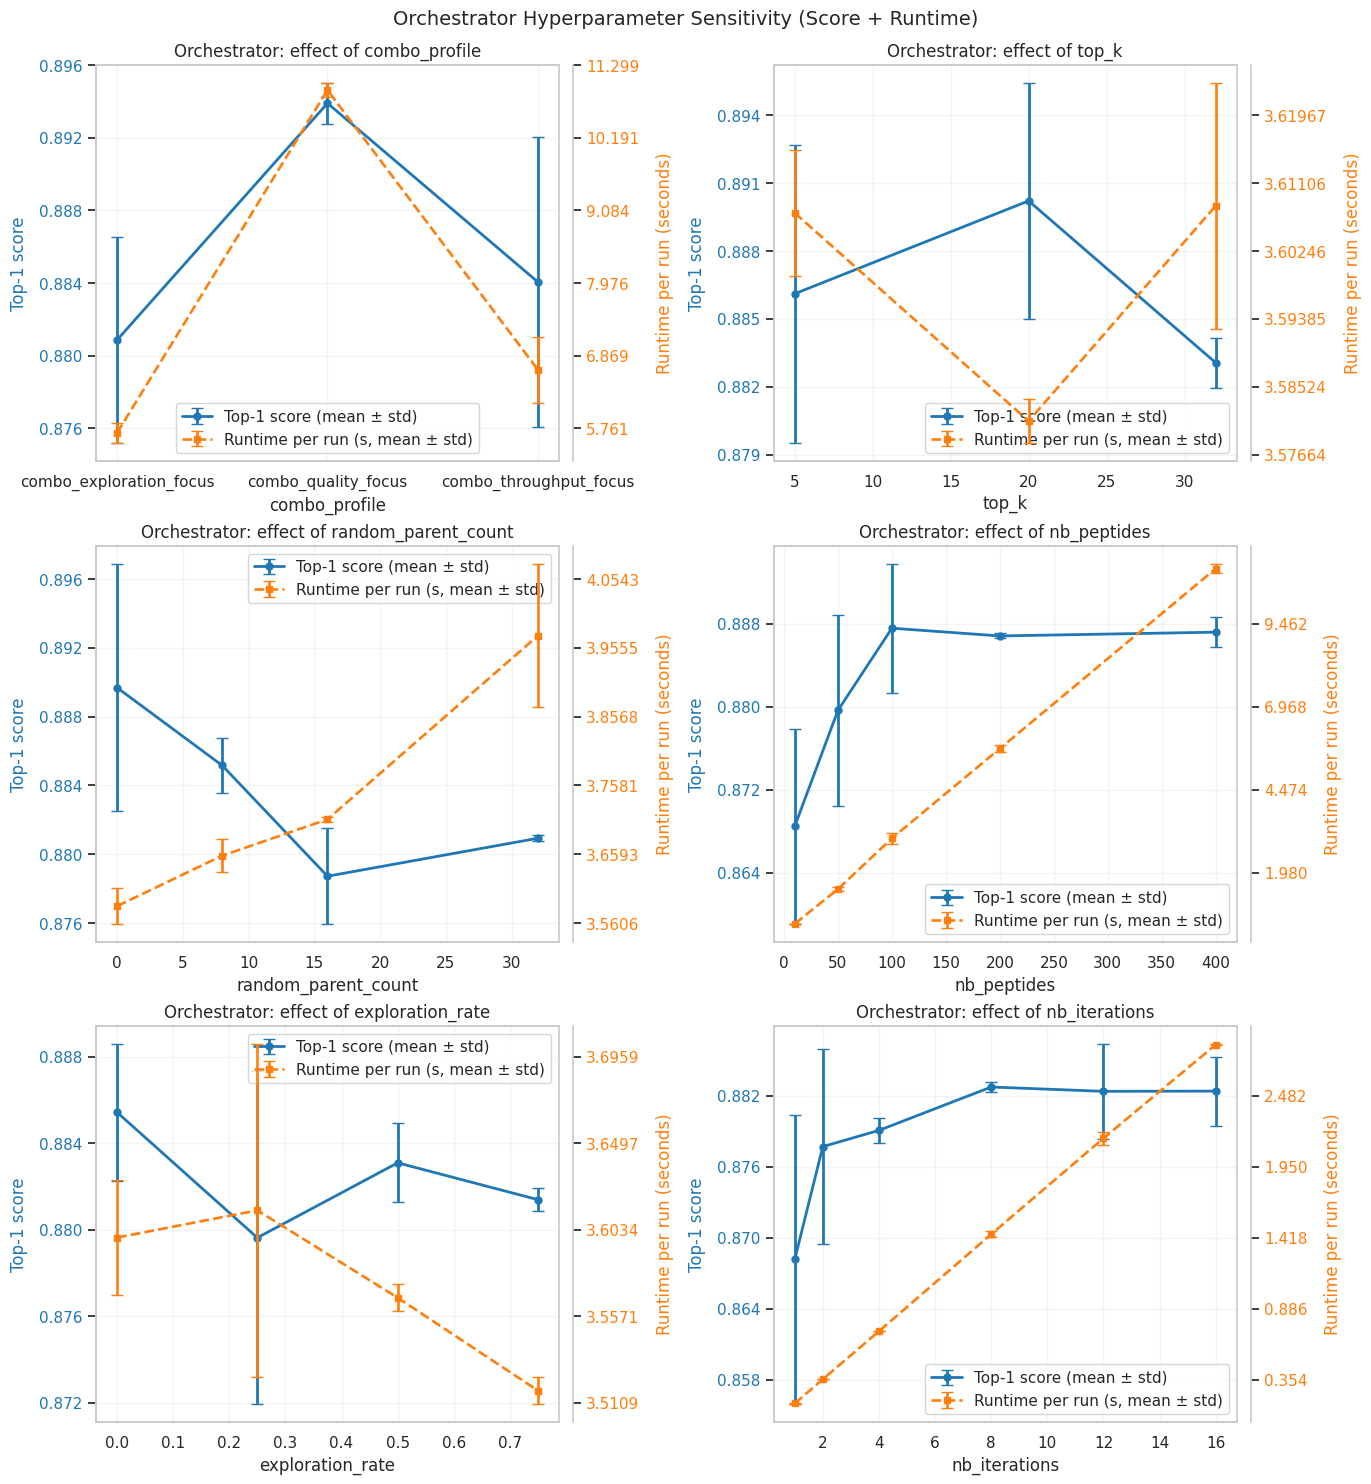

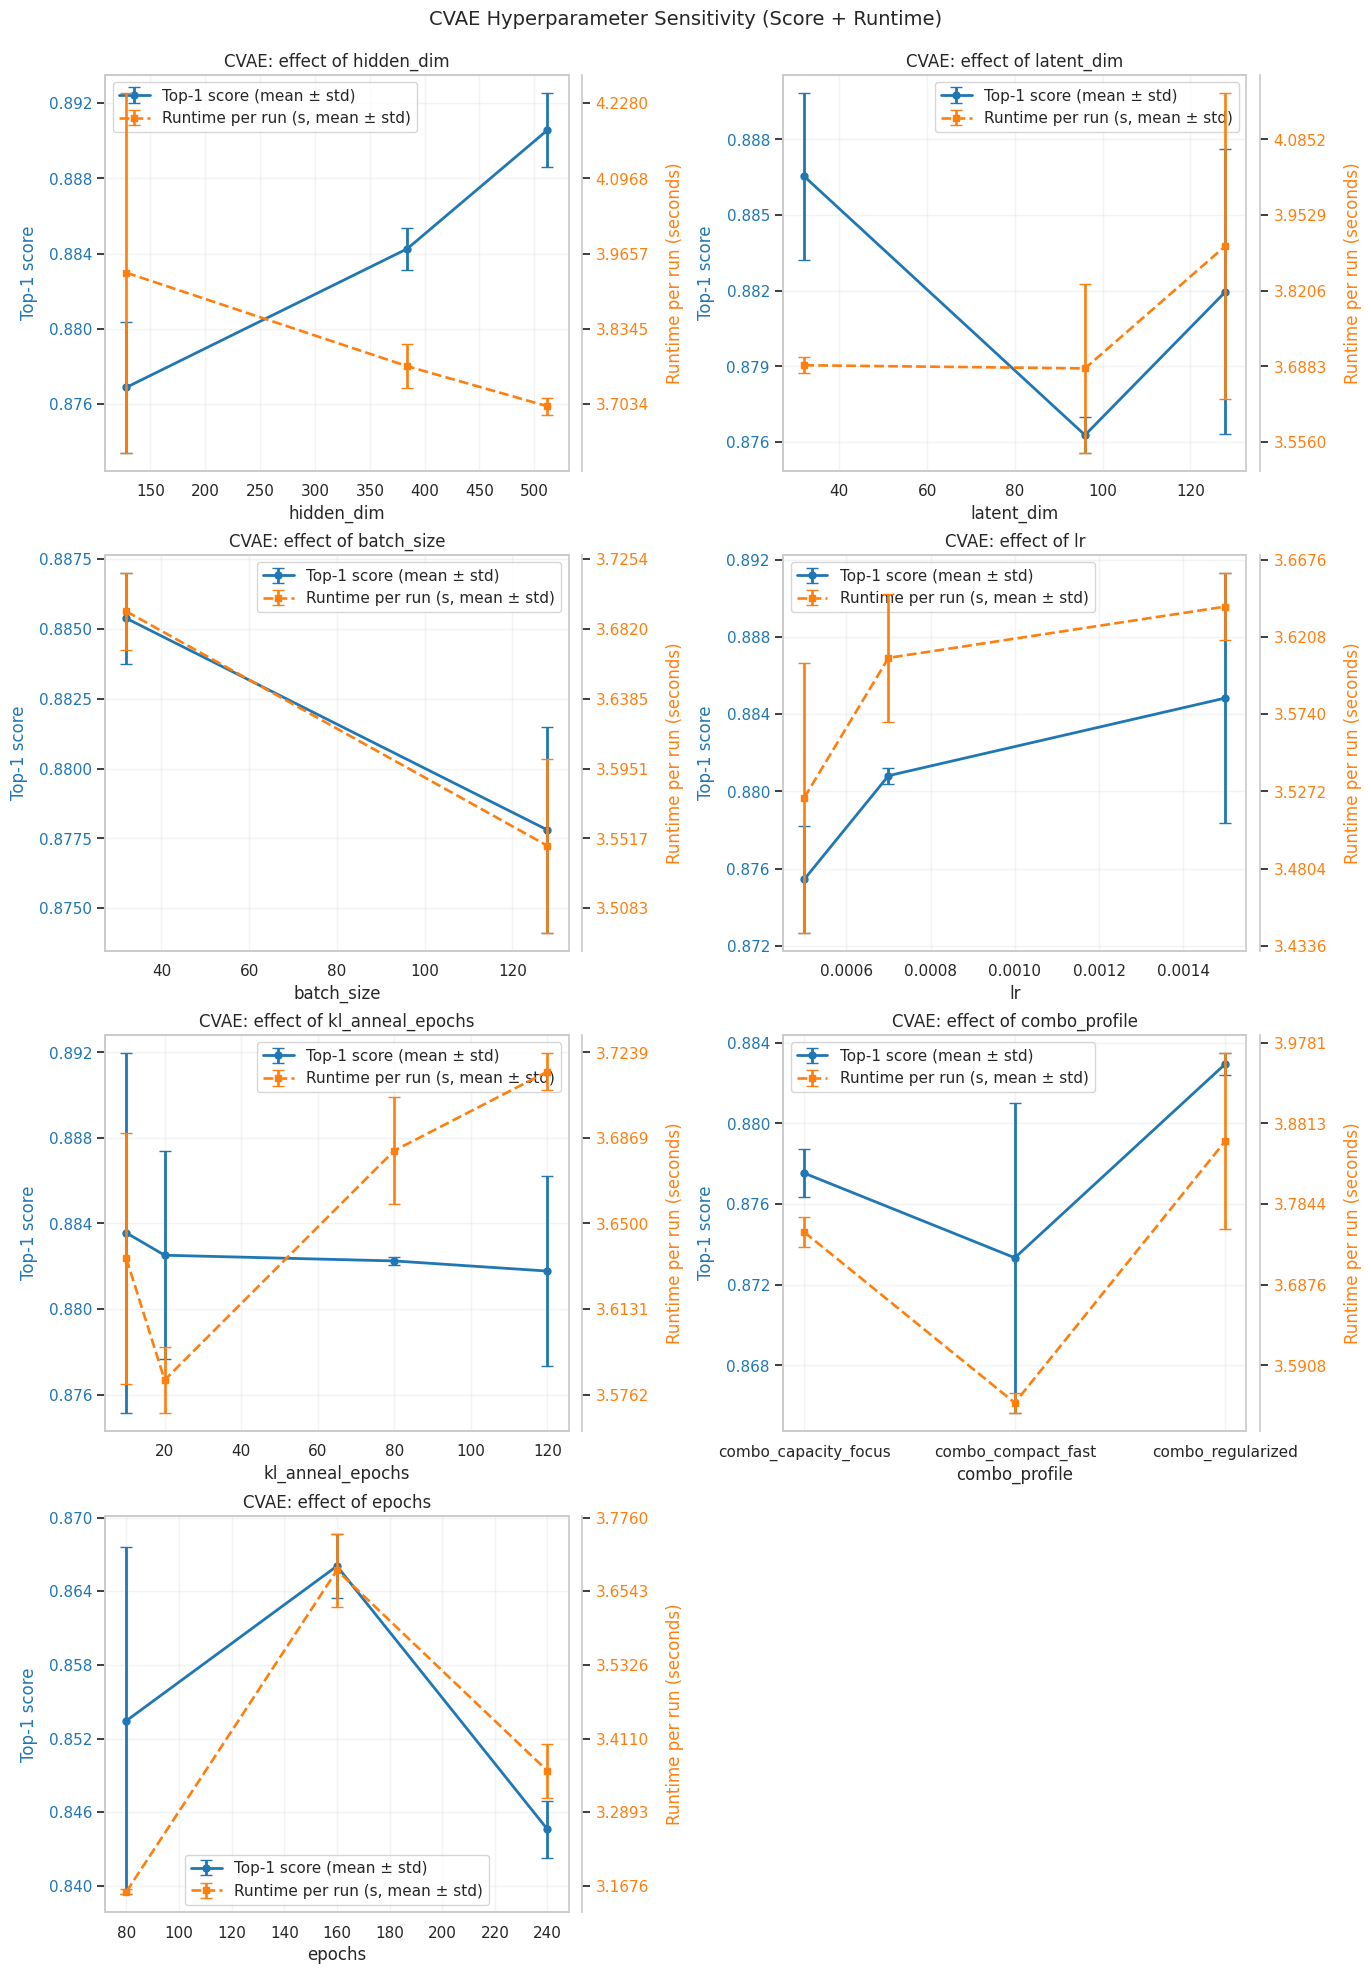

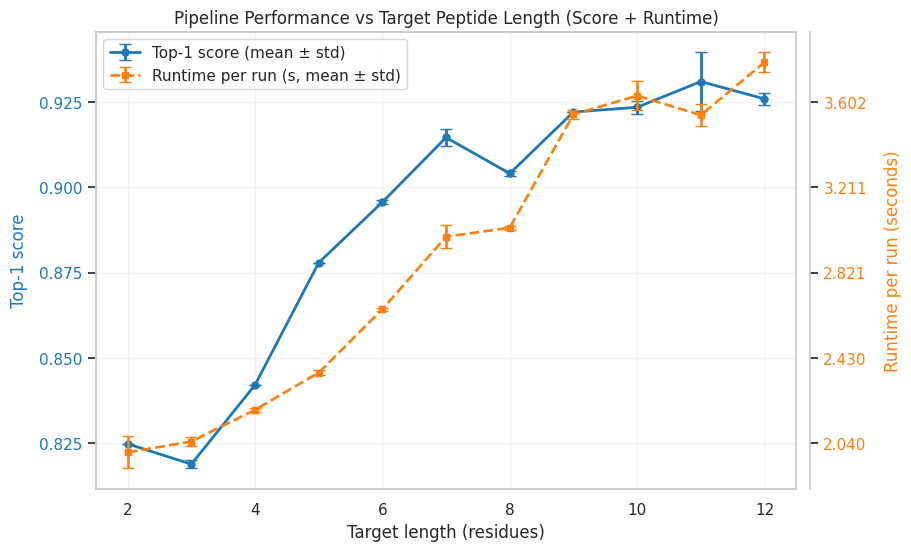

,method,top1_score_mean,top1_score_std,topk_mean_score_mean,topk_mean_score_std,validity_rate_mean,validity_rate_std,unique_ratio_mean,unique_ratio_std,mean_pairwise_distance_mean,mean_pairwise_distance_std,bigram_entropy_mean,bigram_entropy_std,elapsed_sec_mean,elapsed_sec_std
0,pipeline_reference,0.887097,0.003545,0.877884,0.001285,1.0,0.0,1.0,0.0,0.606061,0.131422,4.653172,0.212459,3.811898,0.095331


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

sns.set_theme(style="whitegrid")

def align_dual_y_ticks(ax, ax2, n_ticks=6):
    ax.yaxis.set_major_locator(MaxNLocator(nbins=n_ticks))
    ax2.yaxis.set_major_locator(MaxNLocator(nbins=n_ticks))

    y1_ticks = ax.get_yticks()
    y1_min, y1_max = ax.get_ylim()
    y2_min, y2_max = ax2.get_ylim()

    if len(y1_ticks) > 1 and y1_max > y1_min:
        y2_ticks = np.interp(y1_ticks, [y1_min, y1_max], [y2_min, y2_max])
        if len(y2_ticks) > 2:
            ax2.set_yticks(y2_ticks[1:-1])
        else:
            ax2.set_yticks(y2_ticks)

def style_dual_axis(ax, ax2):
    ax.grid(True, which='major', axis='both', alpha=0.22, zorder=0)
    ax.set_axisbelow(True)
    ax2.grid(False)

    ax.yaxis.labelpad = 8
    ax2.yaxis.labelpad = 12
    ax2.spines['right'].set_position(('outward', 10))

    align_dual_y_ticks(ax, ax2, n_ticks=6)

def plot_single_parameter_sweep(df, param_name, ax=None):
    if df.empty:
        return
    subset = df[df['param_name'] == param_name].sort_values('param_value')
    if subset.empty:
        return

    try:
        subset['param_value'] = pd.to_numeric(subset['param_value'])
        subset = subset.sort_values('param_value')
    except Exception:
        pass

    if ax is None:
        _, ax = plt.subplots(figsize=(7.4, 4.8))

    ax2 = ax.twinx()

    h1 = ax.errorbar(
        subset['param_value'],
        subset['top1_score_mean'],
        yerr=subset['top1_score_std'].fillna(0.0),
        fmt='-o',
        capsize=4,
        color='tab:blue',
        linewidth=2.0,
        markersize=5,
        zorder=4,
        label='Top-1 score (mean ± std)',
    )
    ax.set_xlabel(param_name)
    ax.set_ylabel('Top-1 score', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')

    h2 = ax2.errorbar(
        subset['param_value'],
        subset['elapsed_sec_mean'],
        yerr=subset['elapsed_sec_std'].fillna(0.0),
        fmt='--s',
        capsize=4,
        color='tab:orange',
        linewidth=1.9,
        markersize=5,
        zorder=5,
        label='Runtime per run (s, mean ± std)',
    )
    ax2.set_ylabel('Runtime per run (seconds)', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    style_dual_axis(ax, ax2)
    ax.legend([h1, h2], ['Top-1 score (mean ± std)', 'Runtime per run (s, mean ± std)'], loc='best')

if 'orchestrator_results_df' in globals() and not orchestrator_results_df.empty:
    params = [p for p in orchestrator_results_df['param_name'].unique() if p != 'baseline']

    n_cols = 2
    n_rows = max(1, (len(params) + n_cols - 1) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13.6, 4.8 * n_rows), constrained_layout=True)
    axes = np.array(axes).reshape(-1)

    for i, p in enumerate(params):
        plot_single_parameter_sweep(orchestrator_results_df, p, axes[i])
        axes[i].set_title(f'Orchestrator: effect of {p}')

    for j in range(len(params), len(axes)):
        axes[j].axis('off')

    fig.suptitle('Orchestrator Hyperparameter Sensitivity (Score + Runtime)', y=1.02, fontsize=14)
    plt.show()

if 'cvae_results_df' in globals() and not cvae_results_df.empty:
    params = [p for p in cvae_results_df['param_name'].unique() if p != 'baseline']

    n_cols = 2
    n_rows = max(1, (len(params) + n_cols - 1) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13.6, 4.8 * n_rows), constrained_layout=True)
    axes = np.array(axes).reshape(-1)

    for i, p in enumerate(params):
        plot_single_parameter_sweep(cvae_results_df, p, axes[i])
        axes[i].set_title(f'CVAE: effect of {p}')

    for j in range(len(params), len(axes)):
        axes[j].axis('off')

    fig.suptitle('CVAE Hyperparameter Sensitivity (Score + Runtime)', y=1.02, fontsize=14)
    plt.show()

if 'length_sweep_summary_df' in globals() and not length_sweep_summary_df.empty:
    fig, ax = plt.subplots(figsize=(9.0, 5.4), constrained_layout=True)
    metrics = length_sweep_summary_df.sort_values('target_length').copy()

    ax2 = ax.twinx()

    h1 = ax.errorbar(
        metrics['target_length'],
        metrics['top1_score_mean'],
        yerr=metrics['top1_score_std'].fillna(0.0),
        fmt='-o',
        capsize=4,
        color='tab:blue',
        linewidth=2.0,
        markersize=5,
        zorder=4,
        label='Top-1 score (mean ± std)',
    )
    ax.set_xlabel('Target length (residues)')
    ax.set_ylabel('Top-1 score', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax.set_title('Pipeline Performance vs Target Peptide Length (Score + Runtime)')

    h2 = ax2.errorbar(
        metrics['target_length'],
        metrics['elapsed_sec_mean'],
        yerr=metrics['elapsed_sec_std'].fillna(0.0),
        fmt='--s',
        capsize=4,
        color='tab:orange',
        linewidth=1.9,
        markersize=5,
        zorder=5,
        label='Runtime per run (s, mean ± std)',
    )
    ax2.set_ylabel('Runtime per run (seconds)', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

    style_dual_axis(ax, ax2)
    ax.legend([h1, h2], ['Top-1 score (mean ± std)', 'Runtime per run (s, mean ± std)'], loc='best')

    plt.show()

if 'pipeline_reference_summary_df' in globals() and not pipeline_reference_summary_df.empty:
    display(pipeline_reference_summary_df)

In [ ]:
import gc
gc.collect()
if "torch" in globals() and torch.cuda.is_available():
    torch.cuda.empty_cache()